# Manual EDA

The auto-profile in notebook 02 covers raw distributions. This one asks the questions that matter for the model: **which engineered features actually move with returns**, how returns split across categories, and whether orders fall into natural risk clusters.

**Setup.** This notebook works on the fully assembled feature matrix, which is why it sits after the feature blocks rather than beside the auto-profile in notebook 02.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import INTERIM, ROOT
from src.models import time_split

FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)
SURFACE, GRID, INK, MUTED, BASE = "#fcfcfb", "#e1e0d9", "#0b0b0b", "#52514e", "#c3c2b7"
POS, NEG, SLOT1, SLOT2 = "#2a78d6", "#e34948", "#2a78d6", "#eb6834"
CUTOFF, CATS = "2015-07-01", ["deviceID", "paymentMethod"]
DROP = ["orderID", "orderDate", "customerID", "any_return"]

df = pd.read_parquet(INTERIM / "orders.parquet")
for block in ["basket", "customer", "article"]:
    df = df.merge(pd.read_parquet(INTERIM / f"{block}.parquet"), on="orderID", how="left")
df.shape

(738698, 40)

## Correlation with returns

**Correlation with the target.** On a binary outcome this is the point-biserial correlation, mathematically identical to Pearson. It only detects *linear* association — which is precisely why the tree beats it, since the real signal is a sharp jump between one line and two, not a gradient.

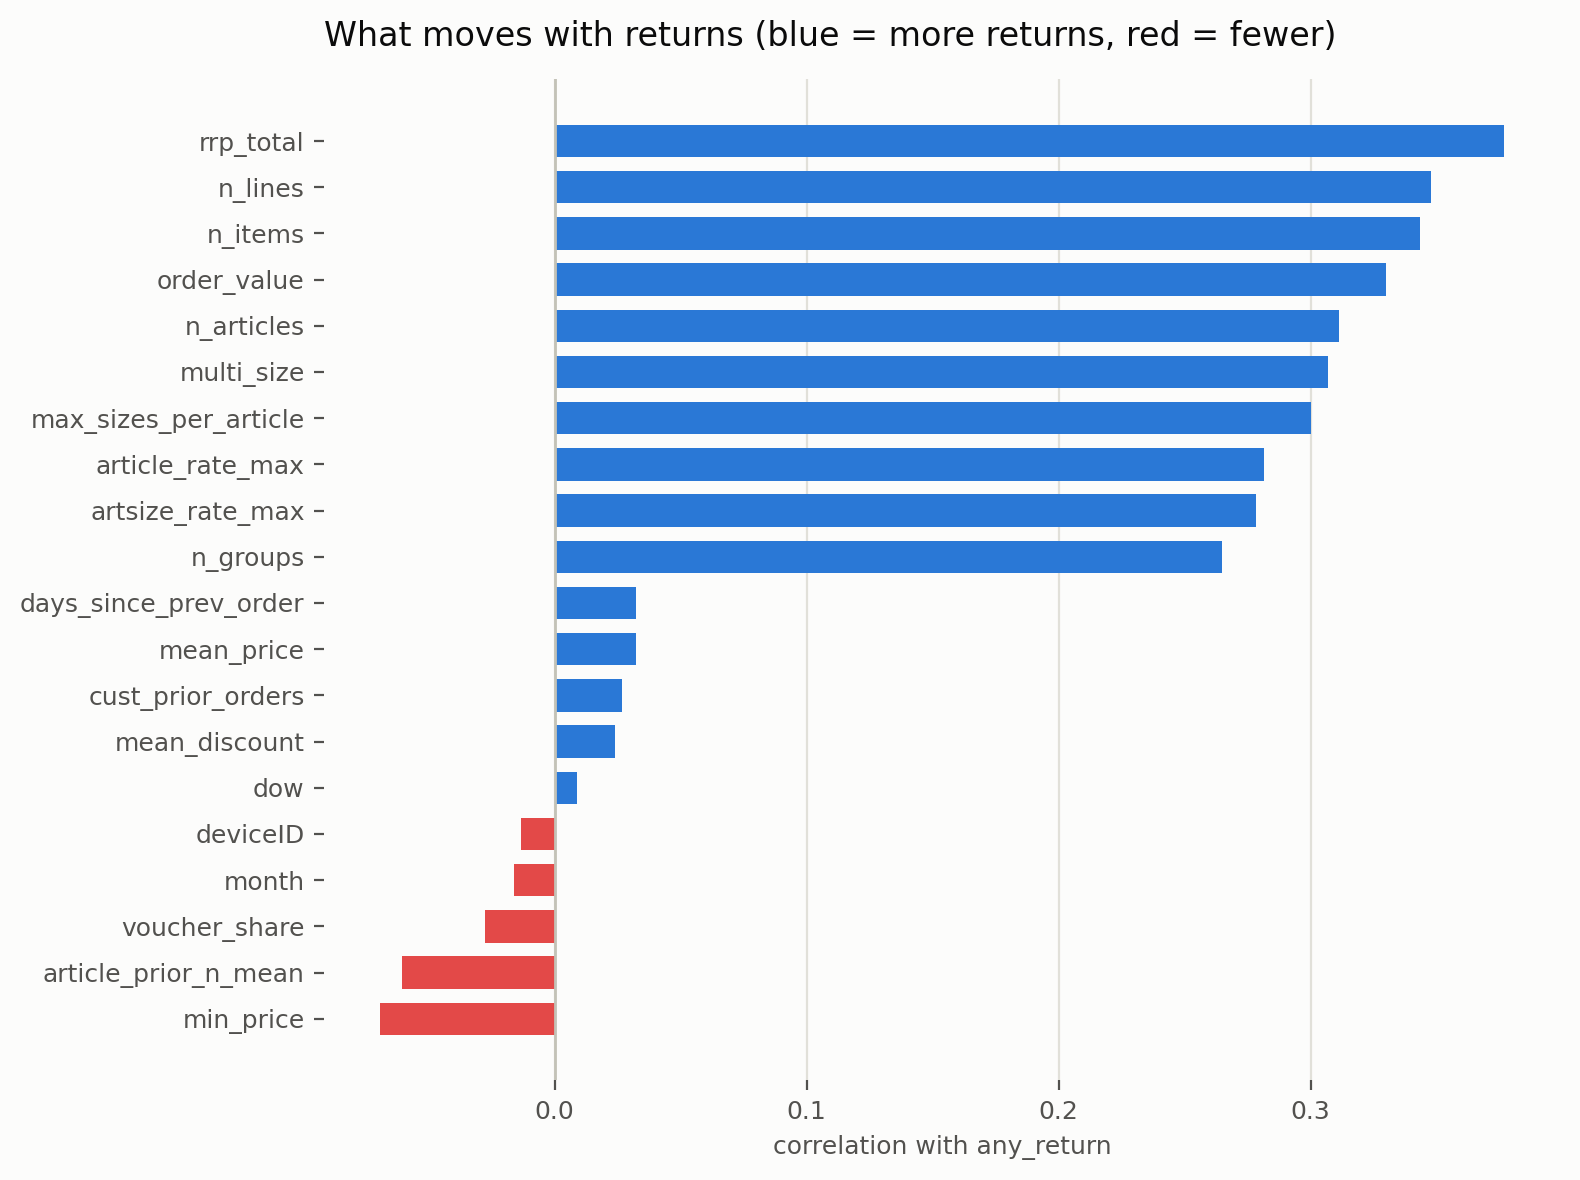

cust_past_return_rate    0.2326
price_spread             0.2380
n_groups                 0.2648
artsize_rate_max         0.2785
article_rate_max         0.2813
max_sizes_per_article    0.3001
multi_size               0.3067
n_articles               0.3113
order_value              0.3300
n_items                  0.3433
n_lines                  0.3476
rrp_total                0.3767
dtype: float64

In [2]:
num = df.select_dtypes("number").drop(columns=["any_return"], errors="ignore")
corr = num.corrwith(df.any_return).dropna().sort_values()
top = pd.concat([corr.head(10), corr.tail(10)])

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.barh(top.index, top.values, color=[NEG if v < 0 else POS for v in top.values], height=0.7, zorder=3)
ax.axvline(0, color=BASE, linewidth=1, zorder=4)
ax.grid(True, axis="x", color=GRID, linewidth=0.8, linestyle="-", zorder=1)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("correlation with any_return", color=MUTED, fontsize=9)
ax.set_title("What moves with returns (blue = more returns, red = fewer)", color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "correlation_returns.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()
corr.tail(12).round(4)

## Return rate by category

**Return rate by category**, with a minimum count so tiny groups do not produce noise masquerading as signal. Payment method spreads from 69% down to 38%; month and device barely move, so seasonality is not the story here.

In [3]:
def rate_by(col, min_n=500):
    g = df.groupby(col).any_return.agg(["mean", "size"]).rename(columns={"mean": "return_rate", "size": "n"})
    return g[g.n >= min_n].sort_values("return_rate", ascending=False)

for col in ["paymentMethod", "deviceID", "month"]:
    print(f"--- {col}")
    print(rate_by(col).round(4).to_string())
    print()

--- paymentMethod
               return_rate       n
paymentMethod                     
BPRG                0.6906  552384
BPPL                0.6771     802
KKE                 0.5589   32484
PAYPALVC            0.4643   61095
CBA                 0.4505   69674
VORAUS              0.4418    9800
BPLS                0.4190    4613
NN                  0.3804    7747

--- deviceID
          return_rate       n
deviceID                     
2              0.6397  520353
5              0.6301   42728
3              0.6283  121441
4              0.6105   54160

--- month
       return_rate      n
month                    
5.0         0.6495  82626
3.0         0.6462  73763
4.0         0.6452  72298
1.0         0.6422  58604
2.0         0.6409  57123
6.0         0.6350  83693
9.0         0.6305  68101
11.0        0.6297  33100
10.0        0.6270  37090
12.0        0.6212  27025
8.0         0.6198  70029
7.0         0.6187  75246



## Bracketing is the clearest split

**The headline cuts.** Same article in two or more sizes returns 95.7% of the time against 56.7% otherwise. That is close to a deterministic rule, and it is observable at checkout before anything ships.

In [4]:
splits = pd.DataFrame([
    {"cut": "single-line order", "rate": df.loc[df.n_lines == 1, "any_return"].mean(), "n": int((df.n_lines == 1).sum())},
    {"cut": "multi-line order", "rate": df.loc[df.n_lines > 1, "any_return"].mean(), "n": int((df.n_lines > 1).sum())},
    {"cut": "no size bracketing", "rate": df.loc[df.multi_size == 0, "any_return"].mean(), "n": int((df.multi_size == 0).sum())},
    {"cut": "same article, 2+ sizes", "rate": df.loc[df.multi_size == 1, "any_return"].mean(), "n": int((df.multi_size == 1).sum())},
    {"cut": "no colour bracketing", "rate": df.loc[df.multi_color == 0, "any_return"].mean(), "n": int((df.multi_color == 0).sum())},
    {"cut": "same article, 2+ colours", "rate": df.loc[df.multi_color == 1, "any_return"].mean(), "n": int((df.multi_color == 1).sum())},
    {"cut": "first-time customer", "rate": df.loc[df.cust_prior_orders == 0, "any_return"].mean(), "n": int((df.cust_prior_orders == 0).sum())},
    {"cut": "has order history", "rate": df.loc[df.cust_prior_orders > 0, "any_return"].mean(), "n": int((df.cust_prior_orders > 0).sum())},
])
splits.round(4)

,cut,rate,n
0,single-line order,0.3563,195137
1,multi-line order,0.7352,543561
2,no size bracketing,0.5674,610297
3,"same article, 2+ sizes",0.9570,128401
4,no colour bracketing,0.5954,569641
5,"same article, 2+ colours",0.7688,169057
6,first-time customer,0.6053,314011
7,has order history,0.6572,424687


## Clusters

**Clustering.** Standardising first is mandatory: KMeans uses Euclidean distance, so without it `order_value` (range $0–28,000) would swamp `multi_size` (0 or 1). `n_init=5` restarts from several seeds because KMeans converges to local optima.

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

CLUSTER_FEATS = ["n_lines", "n_items", "order_value", "mean_discount", "max_sizes_per_article",
                 "max_colors_per_article", "cust_prior_orders", "cust_past_return_rate"]
Z = df[CLUSTER_FEATS].fillna(df[CLUSTER_FEATS].median())
Zs = StandardScaler().fit_transform(Z)

km = KMeans(n_clusters=5, n_init=5, random_state=0).fit(Zs)
df["cluster"] = km.labels_

profile = df.groupby("cluster").agg(n=("any_return", "size"), return_rate=("any_return", "mean"),
                                    **{f: (f, "mean") for f in CLUSTER_FEATS})
profile = profile.sort_values("return_rate")
profile.round(3)

,n,return_rate,n_lines,n_items,order_value,mean_discount,max_sizes_per_article,max_colors_per_article,cust_prior_orders,cust_past_return_rate
cluster,,,,,,,,,,
1,419470,0.476,1.794,1.775,67.223999,0.150,1.000,1.013,3.205000,0.631
3,160048,0.752,4.373,4.371,147.317001,0.119,1.000,1.669,3.098000,0.638
4,15067,0.783,2.928,2.888,90.986000,0.203,1.129,1.260,63.390999,0.702
2,101102,0.950,3.859,3.821,148.852005,0.144,2.027,1.356,2.873000,0.641
0,43011,0.958,10.193,10.246,358.523010,0.115,1.619,2.086,3.169000,0.643


**Cluster risk profile.** The clusters never see the label, yet separate from a 47.6% to a 95.8% return rate — unsupervised confirmation of what the supervised model learns independently.

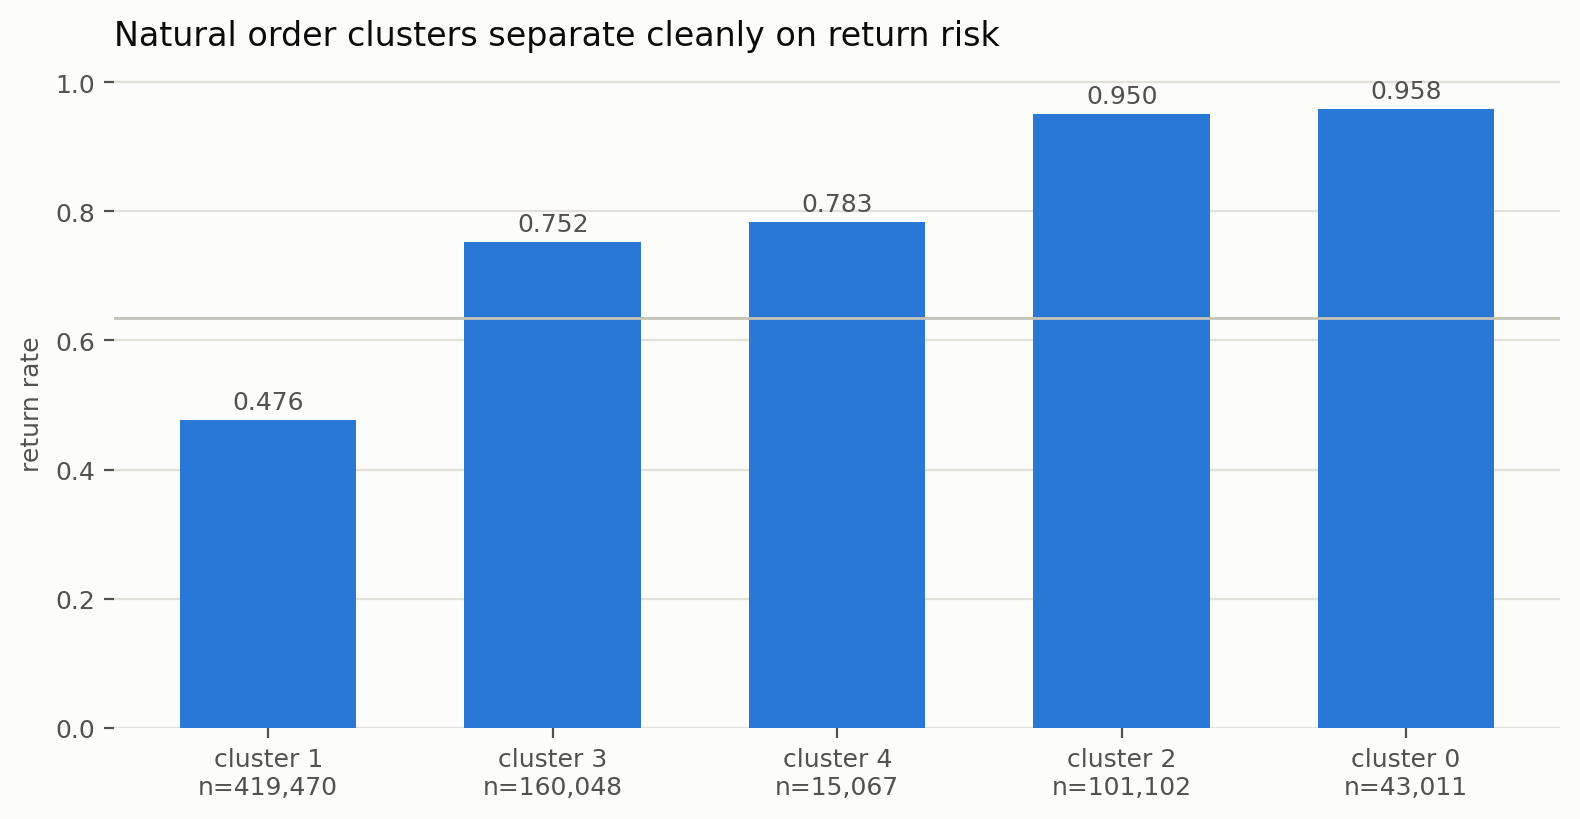

In [6]:
p = profile.reset_index()
labels = [f"cluster {int(c)}\nn={n:,}" for c, n in zip(p.cluster, p.n)]

fig, ax = plt.subplots(figsize=(8, 4.2), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.bar(labels, p.return_rate, color=SLOT1, width=0.62, zorder=3)
ax.axhline(df.any_return.mean(), color=BASE, linewidth=1, zorder=4)
ax.annotate(f"overall {df.any_return.mean():.3f}", (len(labels) - 0.4, df.any_return.mean()),
            xytext=(0, 5), textcoords="offset points", color=MUTED, fontsize=8, ha="right")
for i, v in enumerate(p.return_rate):
    ax.annotate(f"{v:.3f}", (i, v), xytext=(0, 4), textcoords="offset points",
                ha="center", color=MUTED, fontsize=9)
ax.grid(True, axis="y", color=GRID, linewidth=0.8, linestyle="-", zorder=1)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_ylabel("return rate", color=MUTED, fontsize=9)
ax.set_title("Natural order clusters separate cleanly on return risk", color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "cluster_return_rates.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## The four cuts that matter

Four views of the same question — which observable facts at checkout move the return rate. Each panel is a single series, so one colour throughout; the horizontal line is the overall rate for reference. Counts are printed so a tall bar built on few orders cannot masquerade as signal.

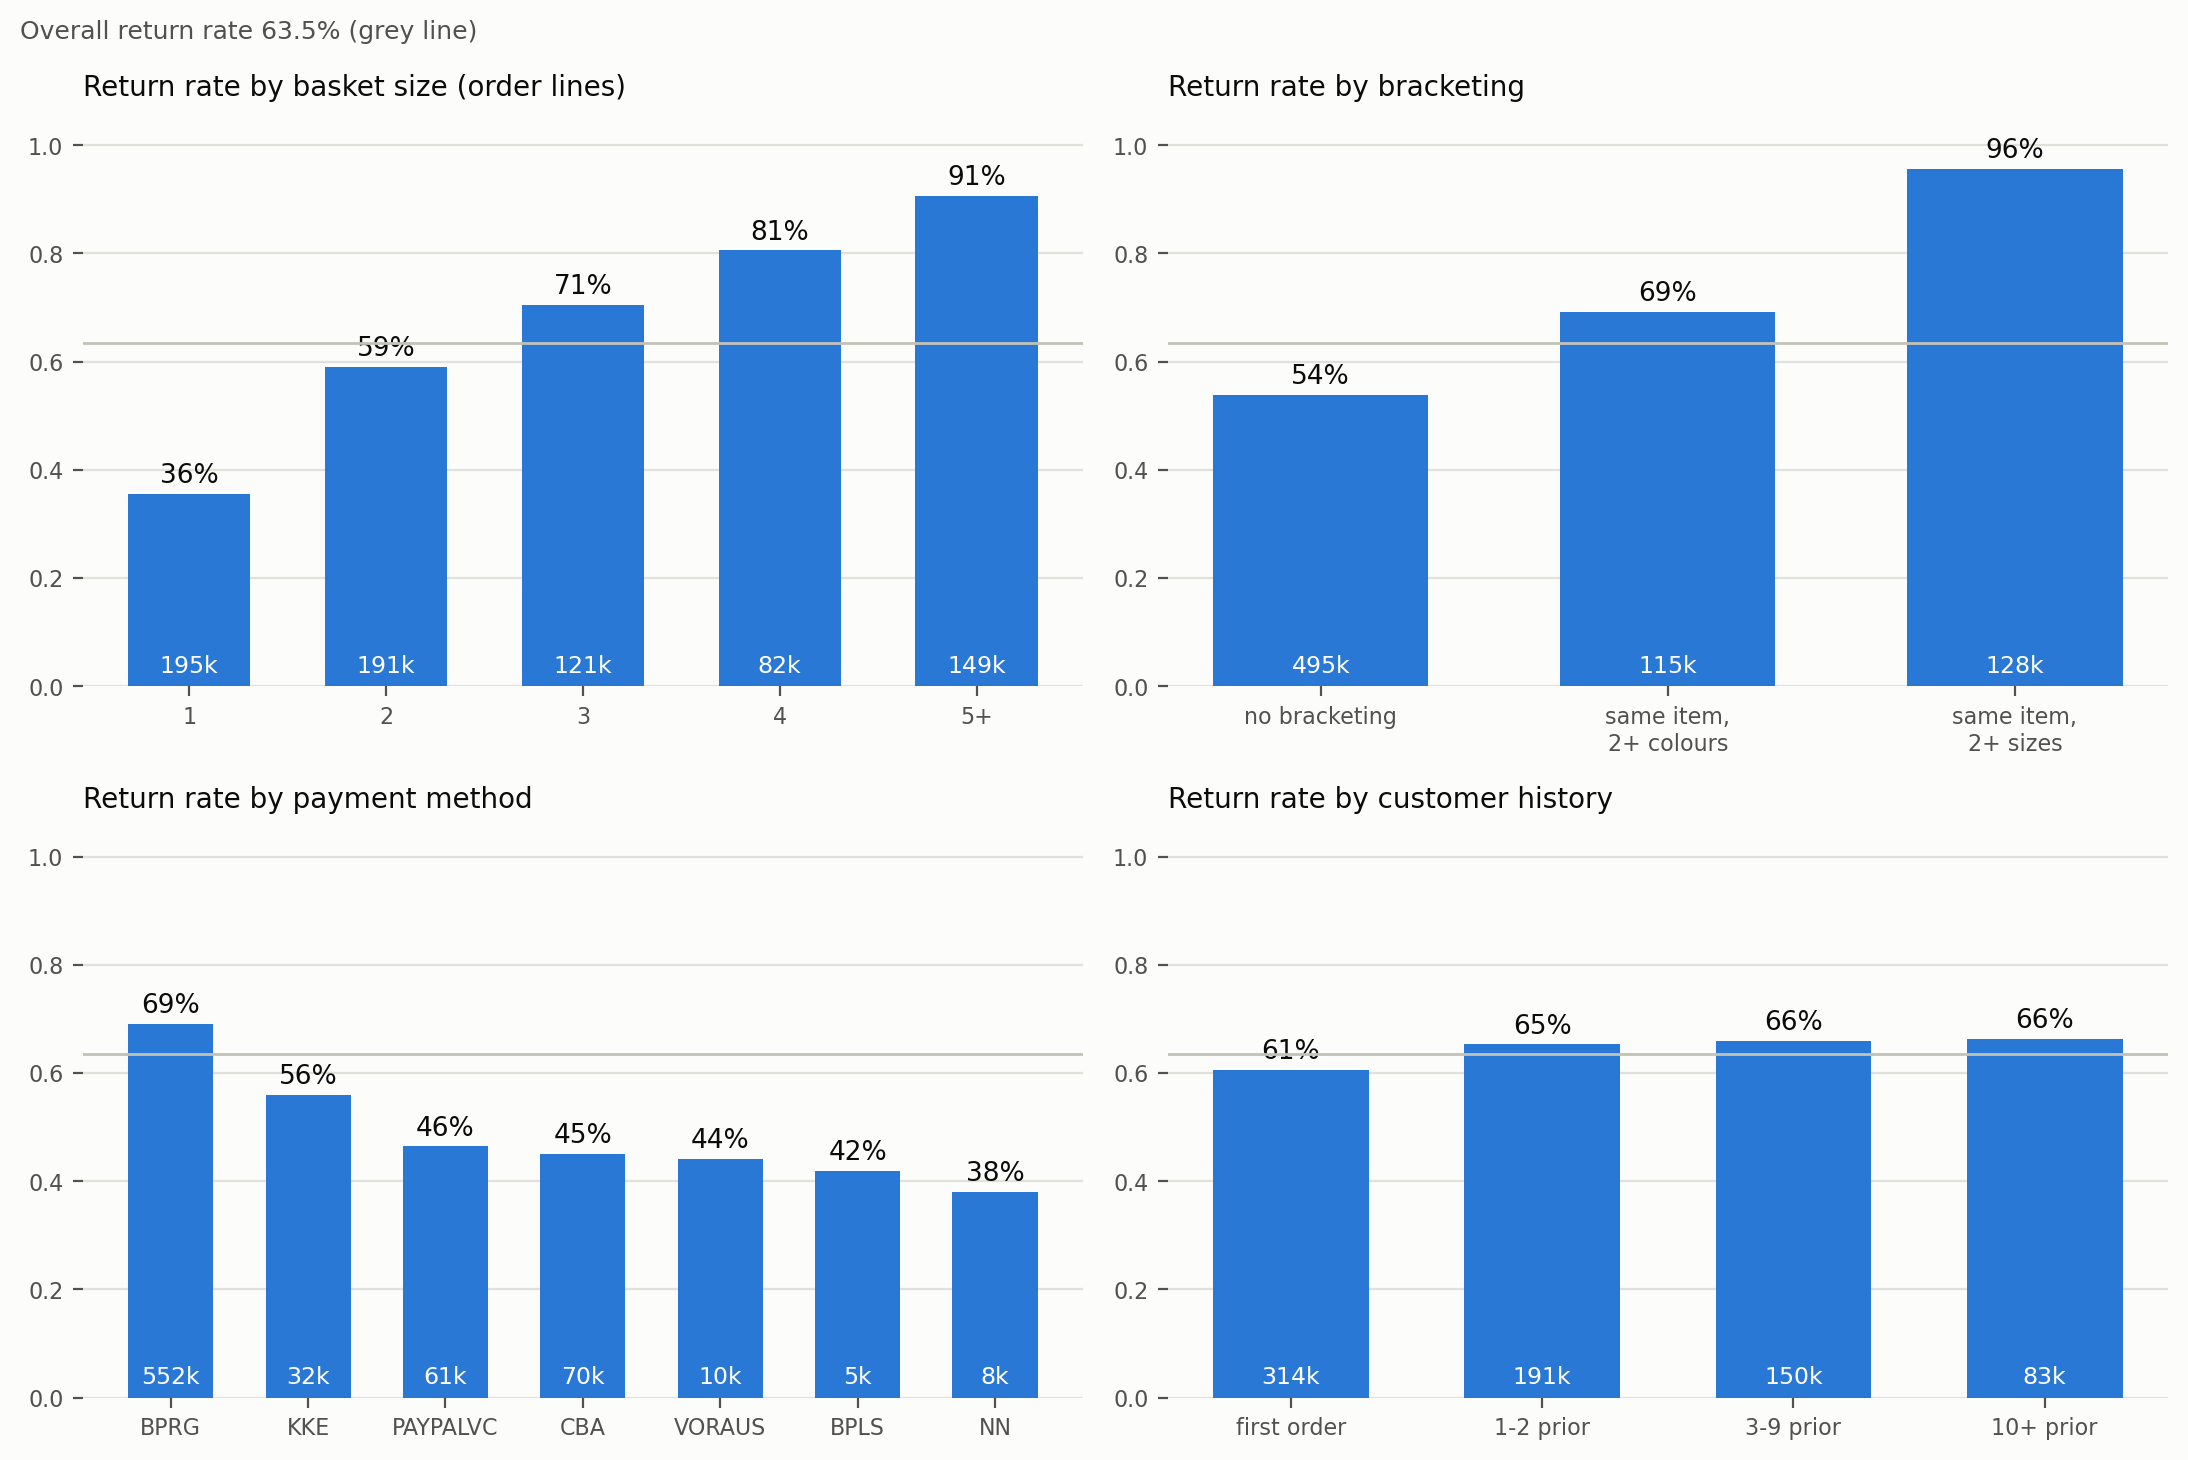

In [7]:
overall = df.any_return.mean()

def bar(ax, labels, rates, counts, title):
    ax.bar(labels, rates, color=SLOT1, width=0.62, zorder=3)
    ax.axhline(overall, color=BASE, linewidth=1, zorder=4)
    for i, (v, n) in enumerate(zip(rates, counts)):
        ax.annotate(f"{v:.0%}", (i, v), xytext=(0, 4), textcoords="offset points",
                    ha="center", color=INK, fontsize=9.5)
        ax.annotate(f"{n/1000:.0f}k", (i, 0), xytext=(0, 5), textcoords="offset points",
                    ha="center", color="#ffffff", fontsize=8.5, fontweight="medium")
    ax.set_title(title, color=INK, fontsize=10, pad=8, loc="left")
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis="y", color=GRID, linewidth=0.8, linestyle="-", zorder=1)
    ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_visible(False)
    ax.tick_params(colors=MUTED, labelsize=8)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.4), dpi=200)
fig.patch.set_facecolor(SURFACE)
for a in axes.flat: a.set_facecolor(SURFACE)

# 1. basket size
bins = df.n_lines.clip(upper=5)
g = df.groupby(bins).any_return.agg(["mean", "size"])
bar(axes[0, 0], ["1", "2", "3", "4", "5+"], g["mean"].values, g["size"].values,
    "Return rate by basket size (order lines)")

# 2. bracketing
brack = pd.Series(np.where(df.multi_size == 1, "same item,\n2+ sizes",
                  np.where(df.multi_color == 1, "same item,\n2+ colours", "no bracketing")), index=df.index)
g = df.groupby(brack).any_return.agg(["mean", "size"]).reindex(
    ["no bracketing", "same item,\n2+ colours", "same item,\n2+ sizes"])
bar(axes[0, 1], list(g.index), g["mean"].values, g["size"].values, "Return rate by bracketing")

# 3. payment method
g = (df.groupby("paymentMethod").any_return.agg(["mean", "size"])
       .query("size >= 2000").sort_values("mean", ascending=False))
bar(axes[1, 0], list(g.index), g["mean"].values, g["size"].values, "Return rate by payment method")

# 4. customer history
hist = pd.cut(df.cust_prior_orders.fillna(0), [-0.1, 0.5, 2.5, 9.5, 1e9],
              labels=["first order", "1-2 prior", "3-9 prior", "10+ prior"])
g = df.groupby(hist).any_return.agg(["mean", "size"])
bar(axes[1, 1], list(g.index), g["mean"].values, g["size"].values, "Return rate by customer history")

fig.suptitle(f"Overall return rate {overall:.1%} (grey line)", color=MUTED, fontsize=9, x=0.01, ha="left")
fig.tight_layout()
fig.savefig(FIGURES / "eda_cuts.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

Basket size and bracketing are the two that move the needle hardest, and both are observable the instant an order is placed. Payment method carries real signal too — the spread from the highest to the lowest method is over thirty points — which is likely a proxy for how committed the shopper is at checkout rather than anything causal about the payment rail itself. Customer history matters least of the four on its own, but it is the single strongest feature in the model once combined with the rest, which is a reminder that a univariate cut and a model's use of a feature are different questions.

## Do returns separate from keeps?

A two-dimensional PCA projection coloured by outcome, beside the distribution of the model's predicted probability for each class. The projection answers whether the classes separate *linearly in the raw feature space*; the prediction histogram answers whether they separate *at all* once the model is allowed to combine features non-linearly.

**Does it separate?** The left panel projects the raw features to two dimensions and colours by outcome: heavy overlap, because the classes are not linearly separable in the raw space. The right panel shows the model's output for the same two groups, which does pull apart. That contrast is the argument for the model — the signal is there, but only once features are combined non-linearly.

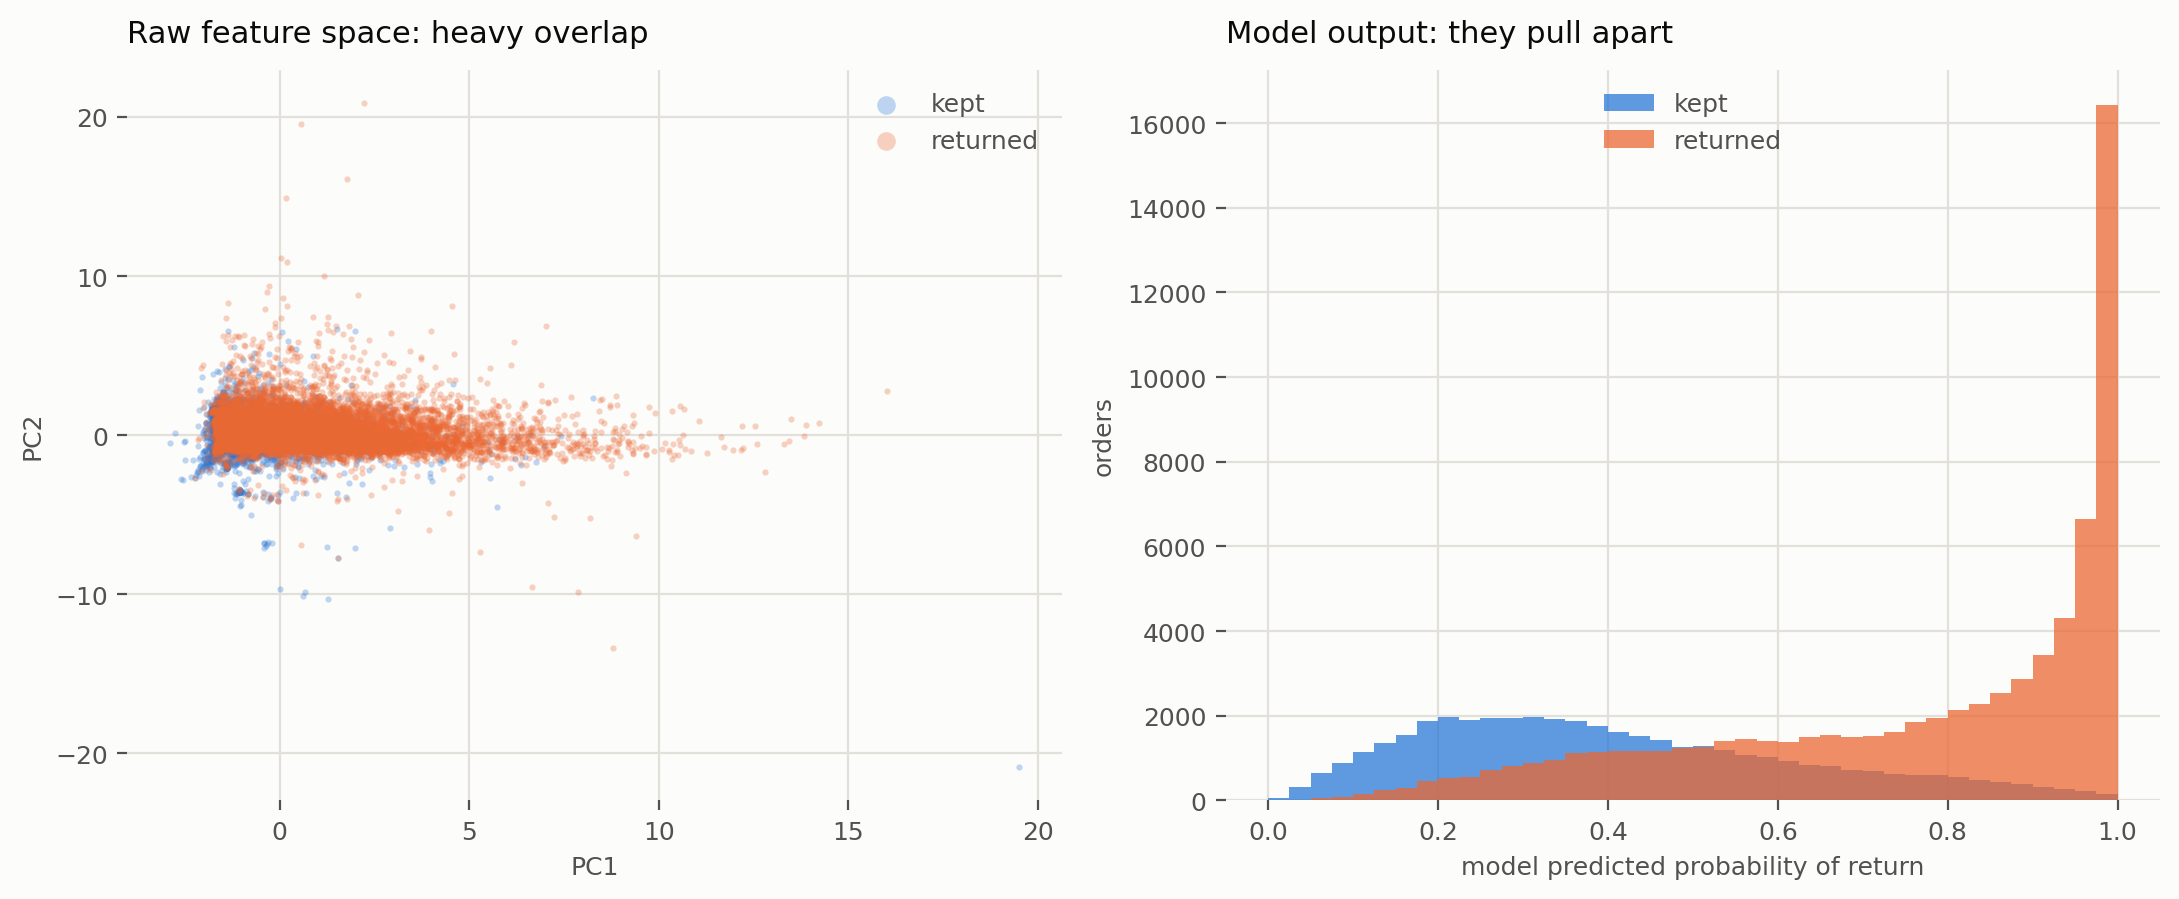

In [8]:
from sklearn.decomposition import PCA

KEPT, RETURNED = "#2a78d6", "#eb6834"
SAMPLE_N = 25_000

samp = df.sample(SAMPLE_N, random_state=0)
Zp = samp[CLUSTER_FEATS].fillna(df[CLUSTER_FEATS].median())
Zp = StandardScaler().fit_transform(Zp)
xy = PCA(n_components=2, random_state=0).fit_transform(Zp)
ret = samp.any_return.values.astype(bool)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), dpi=200)
fig.patch.set_facecolor(SURFACE)
for a in (ax1, ax2):
    a.set_facecolor(SURFACE)
    a.grid(True, color=GRID, linewidth=0.8, linestyle="-", zorder=1)
    a.set_axisbelow(True)
    for s in a.spines.values(): s.set_visible(False)
    a.tick_params(colors=MUTED, labelsize=9)

ax1.scatter(xy[~ret, 0], xy[~ret, 1], s=5, c=KEPT, alpha=0.30, linewidths=0, label="kept", zorder=3)
ax1.scatter(xy[ret, 0], xy[ret, 1], s=5, c=RETURNED, alpha=0.30, linewidths=0, label="returned", zorder=3)
ax1.set_xlabel("PC1", color=MUTED, fontsize=9)
ax1.set_ylabel("PC2", color=MUTED, fontsize=9)
ax1.set_title("Raw feature space: heavy overlap", color=INK, fontsize=11, pad=10, loc="left")
leg = ax1.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=MUTED, markerscale=3)

val = pd.read_parquet(INTERIM / "predictions.parquet")
bins = np.linspace(0, 1, 41)
ax2.hist(val.loc[val.any_return == 0, "pred"], bins=bins, color=KEPT, alpha=0.75, label="kept", zorder=3)
ax2.hist(val.loc[val.any_return == 1, "pred"], bins=bins, color=RETURNED, alpha=0.75, label="returned", zorder=3)
ax2.set_xlabel("model predicted probability of return", color=MUTED, fontsize=9)
ax2.set_ylabel("orders", color=MUTED, fontsize=9)
ax2.set_title("Model output: they pull apart", color=INK, fontsize=11, pad=10, loc="left")
ax2.legend(loc="upper center", frameon=False, fontsize=9, labelcolor=MUTED)

fig.tight_layout()
fig.savefig(FIGURES / "class_separation.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

**Quantify the overlap** rather than eyeballing it: 37.0% of kept orders score below 0.30 and 66.3% of returned orders score above 0.70.

In [9]:
overlap = pd.DataFrame({
    "class": ["kept", "returned"],
    "n": [int((val.any_return == 0).sum()), int((val.any_return == 1).sum())],
    "mean_pred": [val.loc[val.any_return == 0, "pred"].mean(), val.loc[val.any_return == 1, "pred"].mean()],
    "median_pred": [val.loc[val.any_return == 0, "pred"].median(), val.loc[val.any_return == 1, "pred"].median()],
})
share_kept_low = float((val.loc[val.any_return == 0, "pred"] < 0.3).mean())
share_ret_high = float((val.loc[val.any_return == 1, "pred"] > 0.7).mean())
print(f"kept orders scored below 0.30:      {share_kept_low:.1%}")
print(f"returned orders scored above 0.70:  {share_ret_high:.1%}")
overlap.round(4)

kept orders scored below 0.30:      37.0%
returned orders scored above 0.70:  66.3%


,class,n,mean_pred,median_pred
0,kept,42123,0.4083,0.3711
1,returned,71843,0.7633,0.8539


## Findings

**Cluster sizes alongside their risk.** Share matters as much as rate: the safest cluster is also the largest at 57% of orders, which is precisely the population a coverage product wants to find and price cheaply.

In [10]:
findings = profile.assign(share=lambda d: d.n / d.n.sum())[["n", "share", "return_rate"]]
findings.round(4)

,n,share,return_rate
cluster,,,
1,419470,0.5679,0.4760
3,160048,0.2167,0.7521
4,15067,0.0204,0.7834
2,101102,0.1369,0.9503
0,43011,0.0582,0.9582
